### Basis of the Automation of HEX

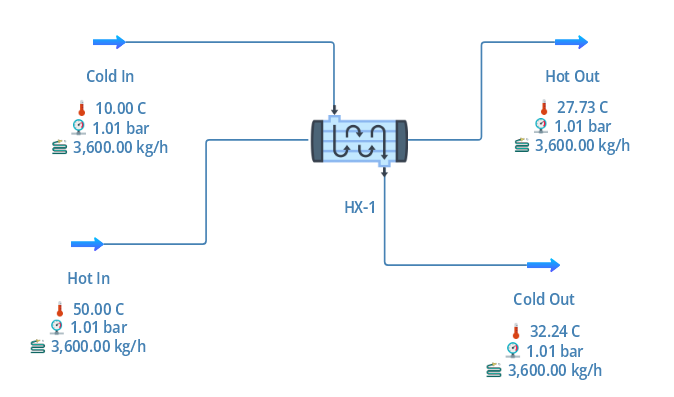

In [1]:
# Import the display function from the IPython.display module
from IPython.display import display

# Import the Image class from the PIL module
from PIL import Image

# Open an image file using the Image class and assign it to the variable Basis_image
Basis_image = Image.open("/workspace/02 Automation of HEX/02 Automation of HEX.dwxmz.png")

# Display the Basis_image using the display function from IPython.display
display(Basis_image)

In [2]:
import os
os.environ["PYTHONNET_RUNTIME"] = "coreclr"
os.environ["DOTNET_SYSTEM_DRAWING_USE_GDIPLUS"] = "1"

import clr
import numpy as np
import time
from datetime import timedelta
from pythonnet import load
from System import Environment, Array, String

# Load .NET Core runtime
load("coreclr")

# Try to import System.IO; fallback to os.chdir if it fails
try:
    from System.IO import Directory, Path, File
    use_dotnet_dir = True
except Exception as e:
    print(f"Note: System.IO import failed ({e}), using os.chdir instead")
    import os
    use_dotnet_dir = False

# Define DWSIM path
dwsimpath = "/usr/local/lib/dwsim/"

# Set working directory
if use_dotnet_dir:
    Directory.SetCurrentDirectory(dwsimpath)
else:
    os.chdir(dwsimpath)

# Add DWSIM assemblies
clr.AddReference(dwsimpath + "CapeOpen.dll")
clr.AddReference(dwsimpath + "DWSIM.Automation.dll")
clr.AddReference(dwsimpath + "DWSIM.Interfaces.dll")
clr.AddReference(dwsimpath + "DWSIM.GlobalSettings.dll")
clr.AddReference(dwsimpath + "DWSIM.SharedClasses.dll")
clr.AddReference(dwsimpath + "DWSIM.Thermodynamics.dll")
clr.AddReference(dwsimpath + "DWSIM.UnitOperations.dll")
clr.AddReference(dwsimpath + "DWSIM.Inspector.dll")
clr.AddReference(dwsimpath + "System.Buffers.dll")
clr.AddReference(dwsimpath + "DWSIM.Thermodynamics.ThermoC.dll")

# Now import DWSIM types
from DWSIM.Interfaces.Enums.GraphicObjects import ObjectType
from DWSIM.Thermodynamics import Streams, PropertyPackages
from DWSIM.UnitOperations import UnitOperations
from DWSIM.Automation import Automation3
from DWSIM.GlobalSettings import Settings

print("DWSIM imports successful!")

DWSIM imports successful!


In [3]:
# Create an instance of the Automation3 class from the DWSIM.Automation module
# This class provides methods for automating tasks in DWSIM, such as creating and manipulating flowsheets
interf = Automation3()

In [4]:
# Set the file path of an existing DWSIM flowsheet to be loaded using the Path.Combine method from the System.IO module
# The flowsheet file path is constructed using the Environment.GetFolderPath method to obtain the path to the desktop folder and the relative path to the flowsheet file
fileNameToLoad = Path.Combine(Environment.GetFolderPath(Environment.SpecialFolder.Desktop), "/workspace/02 Automation of HEX/02 Automation of HEX.dwxmz")

# Load the DWSIM flowsheet using the LoadFlowsheet method of the Automation3 class
# The method takes a single argument, which is the file path of the flowsheet to be loaded
# The method returns a Simulation object that represents the loaded flowsheet
sim = interf.LoadFlowsheet(fileNameToLoad)

### Calling Heat Exchanger as a object

In [5]:
HEX = sim.GetObject("HX-1")
HEX = HEX.GetAsObject()

In [6]:
Calc_mode = HEX.get_CalculationMode()
Calc_mode.ToString()

'ShellandTube_Rating'

In [7]:
Flow_dir = HEX.get_FlowDir()
Flow_dir.ToString()

'CounterCurrent'

In [8]:
Cold_Side_Pressure_Drop = HEX.get_ColdSidePressureDrop()
Cold_Side_Pressure_Drop

3.04793767229421

In [9]:
Hot_Side_Pressure_Drop = HEX.get_HotSidePressureDrop()
Hot_Side_Pressure_Drop

274.62186765275

In [10]:
Cold_Side_Outlet_Temperature = HEX.get_ColdSideOutletTemperature()
Cold_Side_Outlet_Temperature

305.392858671967

In [11]:
Hot_Side_Outlet_Temperature = HEX.get_HotSideOutletTemperature()
Hot_Side_Outlet_Temperature

300.875077821805

In [12]:
Global_HTC = HEX.get_OverallCoefficient()
Global_HTC

122.627580299711

In [13]:
Area = HEX.get_Area()
Area

45.9929164485546

In [14]:
Heat_Exchanged = HEX.get_Q()
Heat_Exchanged

93.0895141339272

In [15]:
Min_temperature_diff = HEX.get_MITA()
Min_temperature_diff

0.0

In [16]:
Heat_loss = HEX.get_HeatLoss()
Heat_loss

0.0

In [17]:
Outlet_Vap_Frac_1 = HEX.get_OutletVaporFraction1()
Outlet_Vap_Frac_1

0.0

In [18]:
Outlet_Vap_Frac_2 = HEX.get_OutletVaporFraction2()
Outlet_Vap_Frac_2

0.0

### Main Results of HEX

In [19]:
Max_Heat_Exchanged = HEX.get_MaxHeatExchange()
Max_Heat_Exchanged

167.294217525684

In [20]:
Thermal_Eff = HEX.get_ThermalEfficiency()
Thermal_Eff

55.6441911207336

In [21]:
LMTD = HEX.get_LMTD()
LMTD

17.7376331870172

In [22]:
LMTD_F = HEX.get_LMTD_F()
LMTD_F

0.930520586791515

Calling the Shell and Tube Properties

In [23]:
ST_Prop = HEX.get_STProperties()

In [24]:
ST_Prop.ReS

2663.837582649019

In [25]:
ST_Prop.ReT

1047.874668561914

In [26]:
ST_Prop.Fs

0.0016145170593775996

In [27]:
ST_Prop.Ft

0.006462117470981992

In [28]:
ST_Prop.Fc

7.813781005455196e-05

In [29]:
ST_Prop.Ff

0.0

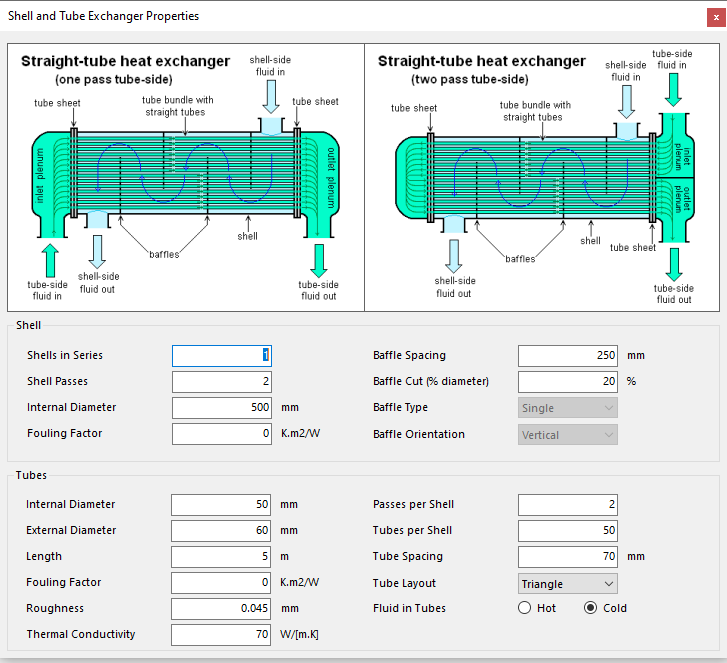

In [30]:
# Import the display function from the IPython.display module
from IPython.display import display

# Import the Image class from the PIL module
from PIL import Image

# Open an image file using the Image class and assign it to the variable Basis_image
Basis_image = Image.open("/workspace/02 Automation of HEX/02 Shell and Tube HE Properties Snap.png")

# Display the Basis_image using the display function from IPython.display
display(Basis_image)

### Automation of HEX for a range of flow rates and temperatures to get the process data

In [31]:
MT1 = sim.GetObject("Cold In")
COLD_IN = MT1.GetAsObject()

In [32]:
MT1 = sim.GetObject("Hot In")
HOT_IN = MT1.GetAsObject()

In [33]:
from tabulate import tabulate

# Define the initial mass flow rate
Cold_mass_flow_rate = COLD_IN.GetMassFlow()
Cold_Inlet_Temp = COLD_IN.GetTemperature()
Hot_mass_flow_rate = HOT_IN.GetMassFlow()
Hot_Inlet_Temp = HOT_IN.GetTemperature()

# Set the solver mode to use the default solver
Settings.SolverMode = 0

# Create an empty list to store the results
results = []

# Iterate 10 times, increasing the mass flow rate by 1 kg/s each time
for i in range(10):
    # Increase the mass flow rate by 1 kg/s
    Cold_mass_flow_rate += 1.0
    Hot_mass_flow_rate += 1.0
    Cold_Inlet_Temp += 1.0
    Hot_Inlet_Temp += 1.0

    # Set the new mass flow rate of the inlet stream
    COLD_IN.SetMassFlow(Cold_mass_flow_rate)
    COLD_IN.SetTemperature(Cold_Inlet_Temp)
    HOT_IN.SetMassFlow(Hot_mass_flow_rate)
    HOT_IN.SetTemperature(Hot_Inlet_Temp)
    
    # Calculate the flowsheet
    errors = interf.CalculateFlowsheet2(sim)
    
    # Get the new flash spec and pressure
    Cold_mass_flow_rate = COLD_IN.GetMassFlow()
    Hot_mass_flow_rate = HOT_IN.GetMassFlow()
    Cold_Inlet_Temp = COLD_IN.GetTemperature()
    Hot_Inlet_Temp = HOT_IN.GetTemperature()
    Thermal_Eff = HEX.get_ThermalEfficiency()
    Cold_Side_Pressure_Drop = HEX.get_ColdSidePressureDrop()
    Hot_Side_Pressure_Drop = HEX.get_HotSidePressureDrop()
    Global_HTC = HEX.get_OverallCoefficient()

    # Append the results to the list
    results.append([Cold_mass_flow_rate, Hot_mass_flow_rate, Cold_Inlet_Temp, Hot_Inlet_Temp, Thermal_Eff, Cold_Side_Pressure_Drop, Hot_Side_Pressure_Drop, Global_HTC])

# Define the headers for the table
headers = ["Cold Mass Flow", "Hot Mass Flow", "Cold Inlet Temp", "Hot Inlet Temp","Thermal Eff", "Cold Side Pressure Drop", "Hot Side Pressure Drop", "Global HTC"]

# Print the results in a table format
print(tabulate(results, headers=headers, tablefmt="grid"))

+------------------+-----------------+-------------------+------------------+---------------+---------------------------+--------------------------+--------------+
|   Cold Mass Flow |   Hot Mass Flow |   Cold Inlet Temp |   Hot Inlet Temp |   Thermal Eff |   Cold Side Pressure Drop |   Hot Side Pressure Drop |   Global HTC |
+==================+=================+===================+==================+===============+===========================+==========================+==============+
|                2 |               2 |            284.15 |           324.15 |       46.3167 |                   6.22411 |                  957.096 |      162.036 |
+------------------+-----------------+-------------------+------------------+---------------+---------------------------+--------------------------+--------------+
|                3 |               3 |            285.15 |           325.15 |       40.2685 |                   9.37461 |                 1984.55  |      188.66  |
+---------------

### Plotting the data to a graphical format

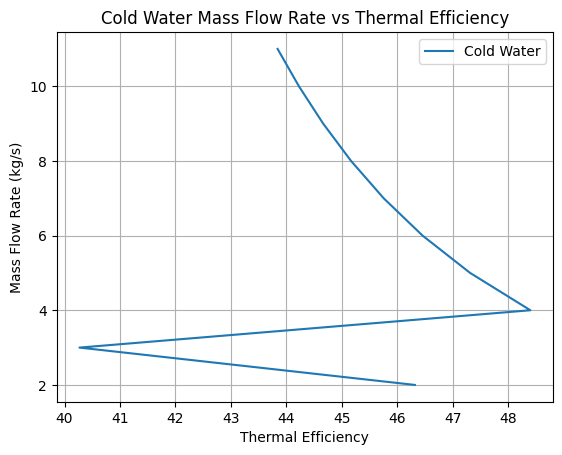

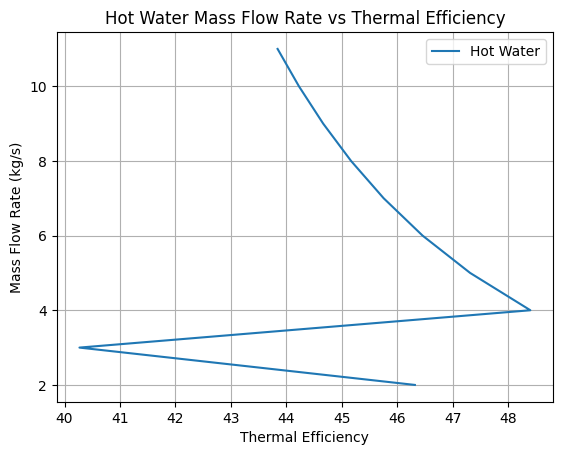

In [34]:
import matplotlib.pyplot as plt

# Extract the data from the results list
cold_mass_flow_rates = [row[0] for row in results]
hot_mass_flow_rates = [row[1] for row in results]
thermal_efficiencies = [row[4] for row in results]

# Plot the cold mass flow rate against thermal efficiency
fig, ax = plt.subplots()
ax.plot(thermal_efficiencies, cold_mass_flow_rates, label='Cold Water')
ax.set_xlabel('Thermal Efficiency')
ax.set_ylabel('Mass Flow Rate (kg/s)')
ax.set_title('Cold Water Mass Flow Rate vs Thermal Efficiency')
ax.legend()
plt.grid()
plt.show()

# Plot the hot mass flow rate against thermal efficiency
fig, ax = plt.subplots()
ax.plot(thermal_efficiencies, hot_mass_flow_rates, label='Hot Water')
ax.set_xlabel('Thermal Efficiency')
ax.set_ylabel('Mass Flow Rate (kg/s)')
ax.set_title('Hot Water Mass Flow Rate vs Thermal Efficiency')
ax.legend()
plt.grid()
plt.show()

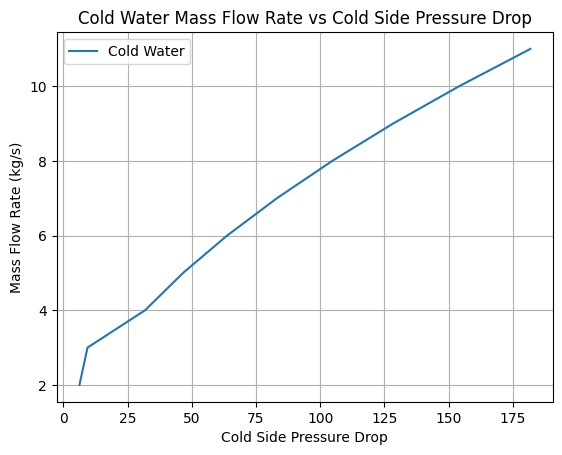

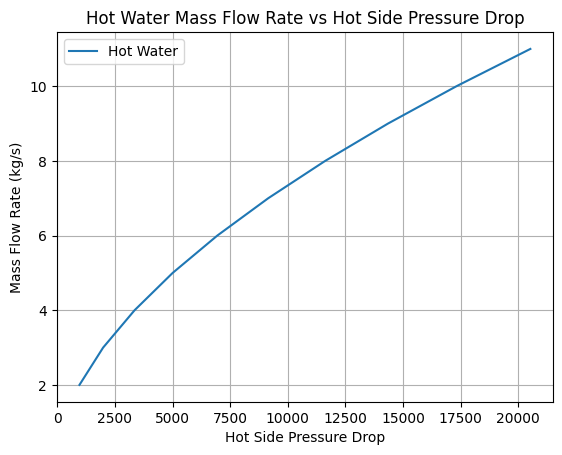

In [35]:
import matplotlib.pyplot as plt

# Extract the data from the results list
cold_mass_flow_rates = [row[0] for row in results]
hot_mass_flow_rates = [row[1] for row in results]
Cold_Side_Pressure_Drop = [row[5] for row in results]
Hot_Side_Pressure_Drop = [row[6] for row in results]

# Plot the cold mass flow rate against thermal efficiency
fig, ax = plt.subplots()
ax.plot(Cold_Side_Pressure_Drop, cold_mass_flow_rates, label='Cold Water')
ax.set_xlabel('Cold Side Pressure Drop')
ax.set_ylabel('Mass Flow Rate (kg/s)')
ax.set_title('Cold Water Mass Flow Rate vs Cold Side Pressure Drop')
ax.legend()
plt.grid()
plt.show()

# Plot the hot mass flow rate against thermal efficiency
fig, ax = plt.subplots()
ax.plot(Hot_Side_Pressure_Drop, hot_mass_flow_rates, label='Hot Water')
ax.set_xlabel('Hot Side Pressure Drop')
ax.set_ylabel('Mass Flow Rate (kg/s)')
ax.set_title('Hot Water Mass Flow Rate vs Hot Side Pressure Drop')
ax.legend()
plt.grid()
plt.show()

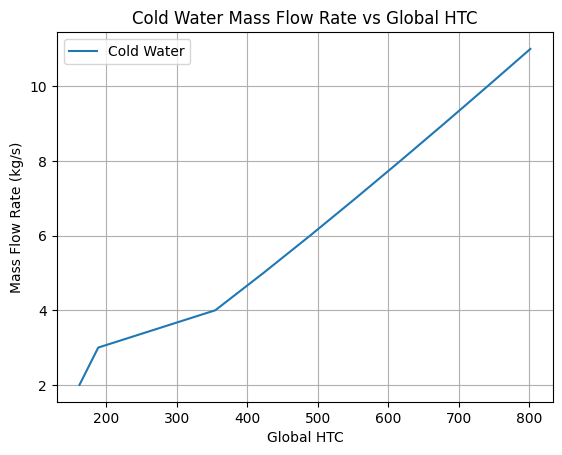

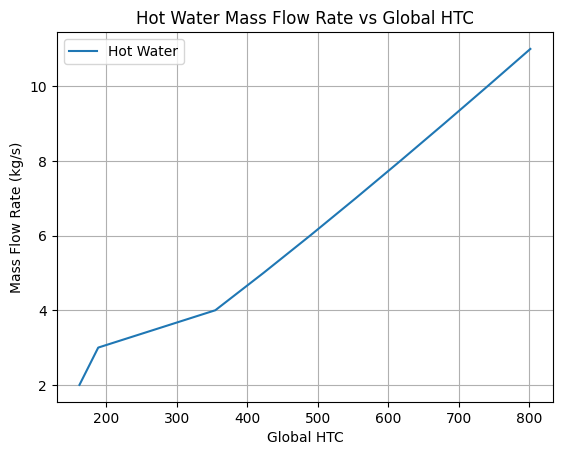

In [36]:
import matplotlib.pyplot as plt

# Extract the data from the results list
cold_mass_flow_rates = [row[0] for row in results]
hot_mass_flow_rates = [row[1] for row in results]
Global_HTC = [row[7] for row in results]

# Plot the cold mass flow rate against thermal efficiency
fig, ax = plt.subplots()
ax.plot(Global_HTC, cold_mass_flow_rates, label='Cold Water')
ax.set_xlabel('Global HTC')
ax.set_ylabel('Mass Flow Rate (kg/s)')
ax.set_title('Cold Water Mass Flow Rate vs Global HTC')
ax.legend()
plt.grid()
plt.show()

# Plot the hot mass flow rate against thermal efficiency
fig, ax = plt.subplots()
ax.plot(Global_HTC, hot_mass_flow_rates, label='Hot Water')
ax.set_xlabel('Global HTC')
ax.set_ylabel('Mass Flow Rate (kg/s)')
ax.set_title('Hot Water Mass Flow Rate vs Global HTC')
ax.legend()
plt.grid()
plt.show()

### Saving the file

In [37]:
# saving the modified version of file at same path

fileNameToSave = Path.Combine(Environment.GetFolderPath(Environment.SpecialFolder.Desktop), "/workspace/02 Automation of HEX/00 Modified_flowsheet.dwxmz")

interf.SaveFlowsheet(sim, fileNameToSave, True)

#### Disclamer

The exercise done was to understand how automation can be used for HEX in DWSim. It does not contains any process data from a live plant under operating conditions but yes the same can be replicated if customer data is available